In [5]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
conn = sqlite3.connect("/Users/marisamacdonald/Desktop/repos/penny_project/tricks.db")

# 2. Query data from a table in the database (replace 'tricks_table' with your actual table name)
data = pd.read_sql_query("SELECT * FROM tricks_table", conn)

# 3. Always close the connection when done
conn.close()

data.head()

,player one choice,player two choice,odds of player 1 win,odds of player 2 win,odds of a tie
0,BBB,BBR,0.404587,0.440858,0.154555
1,BBB,BRB,0.211689,0.664639,0.123672
2,BBB,BRR,0.112684,0.769337,0.117979
3,BBB,RBB,0.001108,0.994951,0.003941
4,BBB,RBR,0.168104,0.694561,0.137335


In [17]:
heatmap_data = data.pivot(
    index="player one choice",
    columns="player two choice",
    values="odds of player 2 win",
)

sequence_order = [
    "BBB",
    "BBR",
    "BRB",
    "BRR",
    "RBB",
    "RBR",
    "RRB",
    "RRR"
]

heatmap_data = heatmap_data.reindex(
    index=sequence_order,
    columns=sequence_order
)

heatmap_data.head()


player two choice,BBB,BBR,BRB,BRR,RBB,RBR,RRB,RRR
player one choice,,,,,,,,
BBB,NaN,0.440858,0.664639,0.769337,0.994951,0.694561,0.967337,0.324980
BBR,0.404587,NaN,0.116255,0.051801,0.935400,0.113890,0.409712,0.008079
BRB,0.211689,0.800680,NaN,0.431953,0.441442,0.406877,0.792197,0.167739
BRR,0.112684,0.882643,0.431549,NaN,0.430725,0.424260,0.026344,0.001142
RBB,0.001108,0.026148,0.423612,0.432422,NaN,0.432367,0.882674,0.112759


ValueError: The number of FixedLocator locations (7), usually from a call to set_ticks, does not match the number of labels (8).

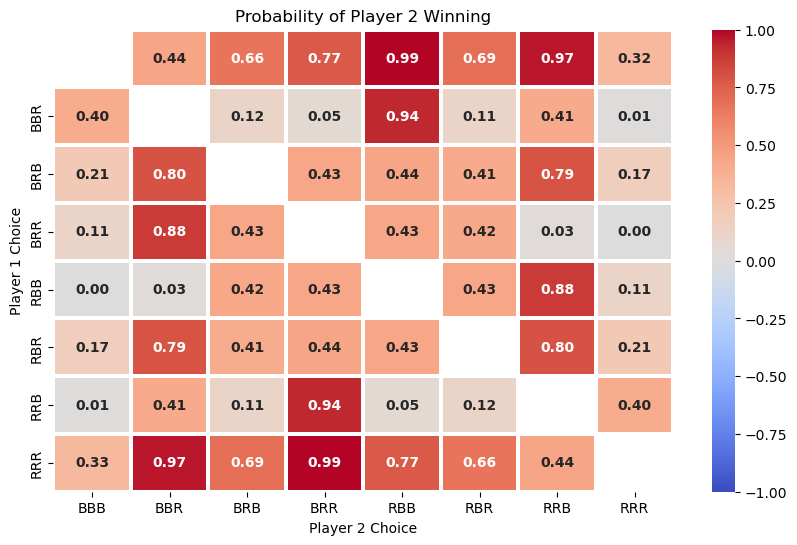

In [20]:
plt.figure(figsize = [10,6])
# print(mask)
sns.heatmap(
    heatmap_data,
    annot = True,
    cmap = 'coolwarm',
    vmin = -1,
    vmax = 1,
    linewidth = 1.5,
    fmt=".2f",
    annot_kws = {'weight': 'bold'}


)

plt.xlabel("Player 2 Choice")
plt.ylabel("Player 1 Choice")
plt.title("Probability of Player 2 Winning")
# Let's fix the labels
# We can make the font larger and remove the redundant labels
ax = plt.gca()
ax.set_yticks(ax.get_yticks()[1:], labels = sequence_order, size = 14)
#ax.set_xticks(ax.get_xticks()[:-1], labels = c.columns[:-1], size = 14)

# Format the colorbar
# Make the colorbar smaller


plt.show()

In [11]:
import sys
print(sys.executable)

/usr/local/bin/python3
